<a href="https://colab.research.google.com/github/MarissaNorlund/Norlund-2025/blob/main/Comet%20Profiling/Comet_Profiling_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Comet Light Curve and Image Reduction with Open-Source Software**
---

* Using FITS data from SARA telescopes to attain a light curve and construct a video using *prose*, an open-source image processing pipeline that utilizes Python.
* This project is an analysis of astronomical data focusing on the variability of celestial objects, using Flexible Image Transport System (FITS) files obtained from the Southeastern Association for Research in Astronomy (SARA) telescopes. This project involves processing these FITS images to generate a light curve that reveals the variability of celestial objects. This is achieved by utilizing prose, an open-source image processing pipeline written in Python, which is specifically designed for astronomical data analysis due to its capabilities in handling large datasets and performing complex photometric calculations. Prose facilitates automated image calibration, photometric analysis, and data visualization, streamlining the workflow for light curve generation. Additionally, prose can be used to construct a time-lapse video. This video complements the light curve analysis by visually illustrating the motion and brightness variations of observed objects, providing a dynamic representation of the data. This approach demonstrates the effectiveness of open-source tools in modern astronomical research, highlighting their role in efficient data reduction and visualization of celestial variability.

# **Timeline**
---

* **Feb. 11, 2025**: Brainstormed project ideas, and decided on using the *prose* astronomy pipeline to create a light curve and a video of a comet taken by Dr. Martha A. Leake.
* **Feb. 13, 2025**: Created Abstract, and copied over FITS files (darks, flats, biases, and images) to a flashdrive.
  * Objects are written inside the collapsed cell.
* **Feb. 14, 2025**: Started working on the code section, and created a file path to be able to call upon and look at fits images.
  * Chose to use *Comet L3 Atlas*.
  * Fits images are able to be viewed without using something like Mira Pro x64 or Adobe Acrobat.
* **Feb. 18, 2025**: Edited the vmin and vmax values in order to view the image better.
* **Feb. 20, 2025**: Made headway in reducing the image of Comet L3 Atlas, but hit some snags with actually getting the comet detected as an extended source.
  * Started looking at other comets to see if I would be able to have an easier time of getting the exteded source detected, but for Comet E3 ZTF, it disappeard when it was processed.
  * Comet 103P didn't show up in the part where I can view all of the header data.
  * Did not try the K2 PanSTARRS Comet because it has no flats, but I might attempt that tomorrow.
* **Feb. 21, 2025**: Kisten made a breakthrough with the video, so now we have a way to create a video sequence. Now, the next thing to do is to have the point source detector align the images on the sources to make for a smoother video.
* **Feb. 25, 2025**: Made a little bit of progress getting the AutoSourceDetection to actually detect and outline the comet, now I just have to get the code to actually work and create a light curve.
* **Mar. 7, 2025**: I was able to achieve a light curve, but I did not use the photometry sequence that was given in the prose book.
  * I used the aperture and auto source detection to be able to do the intensity scale, and used the *aperture.do_photometry()* to get the code to actually run.

## To-Do
---

* Find FITS files of L3 Atlas online to show that this process can be used with other data sources.
* Continue to fix up the light curve, and be able to explain it clearly.
* Start working on the poster visuals, figure out what we want to put on it, and what we want to talk about.
* Make sure that this code can be used "globally" with other fits files.



#### **All following file paths have been copied over to Marissa's flashdrive.**
---
*   **Comet File Paths:**
  * Comet 103 B/R Filters:
      * *Computer/Hitachi/mleake/2023 Sep 26/Comet 103Cousins*
  * Comet E3 ZTF B/V/R Filters:
      * *Computer/Hitachi/mleake/2023 Jan 21/Comet E3 ZTF*
  * Comet K2 PanSTARRS B/V/R Filters: **No Flats**
      * *Computer/Hitachi/mleake/2022 July 22/K2Panstarrs*
  * Comet L3 Atlas B/V/R Filters:
      * *Computer/Hitachi/mleake/2022 Jan 6/Comet L3 Atlas*
  * Comet 67P B/U Filters:
      * *Computer/Hitachi/mleake/2021 Nov 2/Comet 67P*

*   **Other Cool Stuff:** Clusters/Galaxies/Nebulae
  * NGC 288 (Star Cluster) R Filter:
      * *Computer/Hitachi/mleake/2022 Nov 26/NGC288Bessel*
  * NGC 7793 (Spiral Galaxy) B/V/R Filters: **No Flats**
      * *Computer/Hitachi/mleake/2022 Jun 25/NGC 7793_Bessel*
  * M 97 (Planetary Nebula) B/V/R Filters:
      * *Computer/Hitachi/mleake/2022 Jan 6/M 97*
  * M 57/IC 1296 (Planetary Nebula/Barred Spiral Galaxy) B/V/R Filters:
      * *Computer/Hitachi/mleake/2021 Apr 17/M57*

# Code
---

In [ ]:
'''
import shutil

folder_path = '/content/Comet 103P'  # Example: Deleting the 'sample_data' folder
shutil.rmtree(folder_path)
'''

In [ ]:
'''
import os
from glob import glob

folder_to_exclude = "/content/drive"  # Example folder
file_pattern = "*.fits"

for file_path in glob(file_pattern):
    if not file_path.startswith(folder_to_exclude):
        os.remove(file_path)
'''

In [ ]:
!pip install --upgrade 'prose @ git+https://github.com/lgrcia/prose' > /dev/null 2>&1
!pip install astropy > /dev/null 2>&1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from prose import FitsManager, FITSImage, simulations, Sequence, blocks
import os
import matplotlib.pyplot as plt
import numpy as np
import glob

Telescope 'callisto' saved
Telescope 'io' saved
Telescope 'ganymede' saved
Telescope 'europa' saved
Telescope 'artemis' saved
Telescope 'trappist-south' saved
Telescope 'trappist-north' saved
Telescope 'saint-ex' saved
Telescope 'liverpool' saved
Telescope 'spirit' saved
A config file as been created in /root/.prose
downloading ballet model (~30Mb)


In [ ]:
folder = "drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022" # Change folder path here
fm = FitsManager(folder, depth=3)
fm

Parsing FITS:   0%|          | 0/187 [00:00<?, ?it/s]

INFO telescope 0.9m B&C Telescope not found - using default


,date,telescope,filter,type,target,width,height,files
id,,,,,,,,
12,2022-01-06,0.9m B&C Telescope,B,bias,BIAS FRAME,1024,1024,20
7,2022-01-06,0.9m B&C Telescope,B,light,Comet C/2019 L3 Atlas,1024,1024,15
19,2022-01-06,0.9m B&C Telescope,B,dark,DARK FRAME,1024,1024,42
15,2022-01-06,0.9m B&C Telescope,B,flat,FLAT FRAME,1024,1024,18
5,2022-01-06,0.9m B&C Telescope,R,light,Comet C/2019 L3 Atlas,1024,1024,14
24,2022-01-06,0.9m B&C Telescope,R,flat,FLAT FRAME,1024,1024,25
11,2022-01-06,0.9m B&C Telescope,V,bias,BIAS FRAME,1024,1024,22
6,2022-01-06,0.9m B&C Telescope,V,light,Comet C/2019 L3 Atlas,1024,1024,8
13,2022-01-06,0.9m B&C Telescope,V,dark,DARK FRAME,1024,1024,8


Found FITS files:
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_R_0001.fits
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_R_0002.fits
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_R_0003.fits
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_R_0004.fits
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_R_0005.fits
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_R_0006.fits
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_R_0007.fits
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_R_0008.fits
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_V_0009.fits
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_V_0010.fits
drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_V_0011.fits
drive/MyDrive/FITS Images/Comets/Com

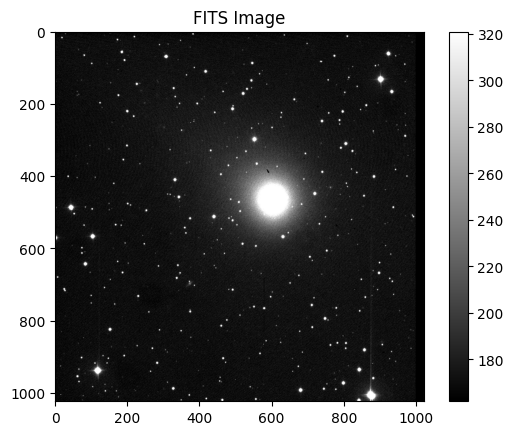

In [ ]:
folder = "drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022" # Change folder path here

# Attempt to find and list all FITS files in the folder and subfolders
fits_files = []
for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(('.fits', '.fit')):
            fits_files.append(os.path.join(root, file))

# Print the list of found FITS files
print("Found FITS files:")
for file_path in fits_files:
    print(file_path)

# Specify the index of the image you want to display (e.g., 0 for the first image)
image_index = 17  # Change this to the desired index

# If FITS files are found and the index is valid, attempt to load and display the specific image
if fits_files and 0 <= image_index < len(fits_files):
    try:
        file_path = fits_files[image_index]  # Get the file path of the desired image
        ref = FITSImage(file_path)  # Load the image
        print("Successfully loaded FITS image:", file_path)

        # Display the image using matplotlib
        plt.figure()
        plt.imshow(ref.data, cmap='gray', vmin=np.percentile(ref.data, 8), vmax=np.percentile(ref.data, 99))
        plt.title('FITS Image')
        plt.colorbar()
        plt.show()

    except Exception as e:
        print("Error loading FITS image:", e)
else:
    print("No FITS files found in the specified folder or subfolders, or invalid image index.")

In [ ]:
bias_folder = os.path.join(folder, "Bias")  # Path to bias folder
dark_folder = os.path.join(folder, "Darks")  # Path to dark folder
flat_folder = os.path.join(folder, "Flats")  # Path to flat folder

all_dark_files = glob.glob(os.path.join(dark_folder, "*.fits"))

In [ ]:
ref = FITSImage(fm.all_images[17])
ref

Image(data=array([[49315., 49938., 52424., ...,   170.,   230.,   149.],
       [  118.,   119.,   165., ...,   164.,   220.,   149.],
       [  115.,   118.,   164., ...,   176.,   226.,   141.],
       ...,
       [  108.,   125.,   164., ...,   181.,   231.,   158.],
       [  119.,   120.,   165., ...,   164.,   250.,   157.],
       [  124.,   129.,   163., ...,   173.,   245.,   153.]]), metadata={'telescope': '0.9m B&C Telescope', 'exposure': 60.0, 'ra': '07 06 00.00', 'dec': '+31 45 00.0', 'filter': 'B', 'date': '2022-01-07T10:04:23.472902', 'jd': 2459586.9197161216, 'object': 'Comet C/2019 L3 Atlas', 'pixel_scale': None, 'gain': 1, 'read_noise': 9, 'overscan': (0, 0), 'path': '/content/drive/MyDrive/FITS Images/Comets/Comet L3 Atlas Jan.6.2022/Comet L3 Atlas_B_0018.fits', 'dimensions': (1024, 1024), 'type': 'light', 'exposure_unit': 's', 'ra_unit': 'deg', 'dec_unit': 'deg', 'jd_scale': 'utc', 'pixel_scale_unit': 'arcsec', 'wcs': "WCSAXES =                    2 / Number of coor

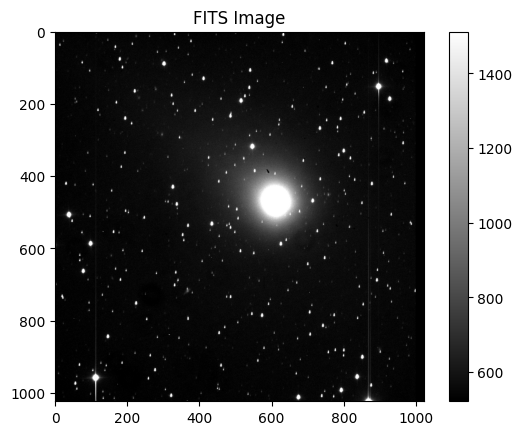

In [ ]:
from prose.core.source import ExtendedSource
from astropy.io import fits

all_dark_files = glob.glob(os.path.join(dark_folder, "*.fits"))

darkfilter_files = []
for dark_file in all_dark_files:
    with fits.open(dark_file) as hdul:
        header = hdul[0].header
        if header.get('EXPTIME', 0) == 60:  # Check for EXPTIME keyword
            darkfilter_files.append(dark_file)

flatfilter_files = []
for flat_file in fm.all_flats:
    with fits.open(flat_file) as hdul:
        header = hdul[0].header
        if header.get('FILTER', '') == 'B':  # Check for FILTER keyword
            flatfilter_files.append(flat_file)

light_frames = []
for image_path in fm.all_images:
    with fits.open(image_path) as hdul:
        image = hdul[0].data
        if header.get('IMAGETYP', '').lower() == 'light':
            light_frames.append(image.data)

calibration = Sequence(
    [
        blocks.Calibration(darks=darkfilter_files, bias=fm.all_bias, flats=flatfilter_files),
    ]
)

for image_path in light_frames:
    image = FITSImage(image_path)
    calibration.run(image, show_progress=False)

plt.imshow(image, cmap='gray', vmin=np.percentile(image.data, 8), vmax=np.percentile(image.data, 99))
plt.title('FITS Image')
plt.colorbar()
plt.show()

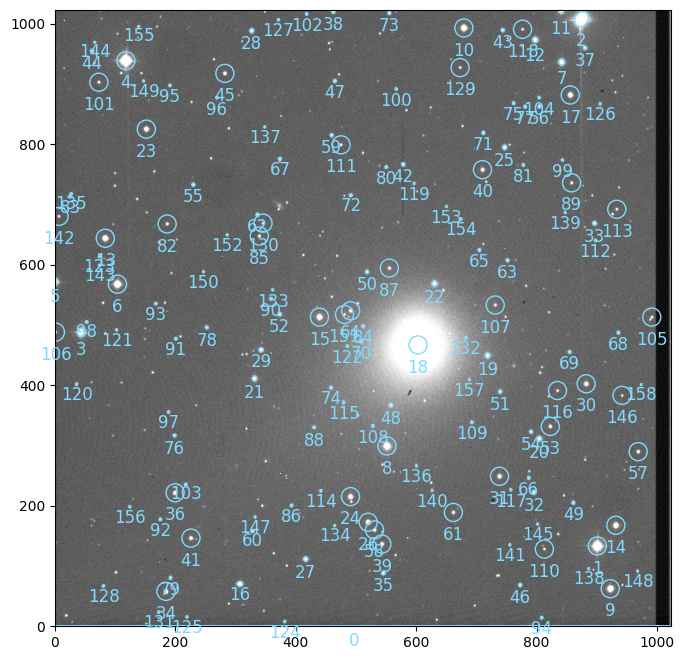

In [ ]:
from prose import blocks

ref = blocks.detection.AutoSourceDetection(min_area=5.0)(ref)
ref.show()

In [ ]:
ref.sources
print(ref.sources[18])

• PointSource 18
  --------------
  coords  603.25  466.73
  a, b     38.97   38.02
  e         0.98


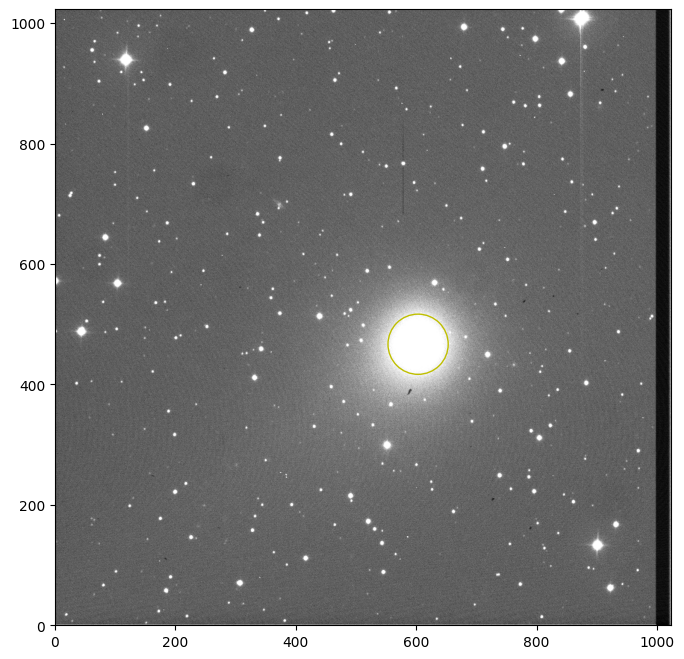

In [ ]:
import matplotlib.pyplot as plt

source = ref.sources[18]
aperture = source.circular_aperture(50, scale=False)

# plotted on top of the image
ref.show(sources=False)
_ = aperture.plot(color="y")

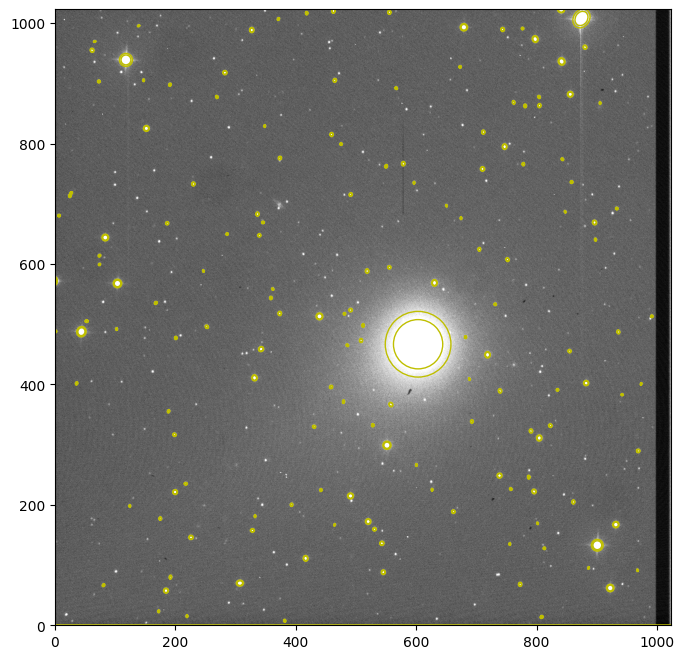

In [ ]:
ref.show(sources=False)

for source in ref.sources:
    aperture = source.annulus()
    _ = aperture.plot(color="y")

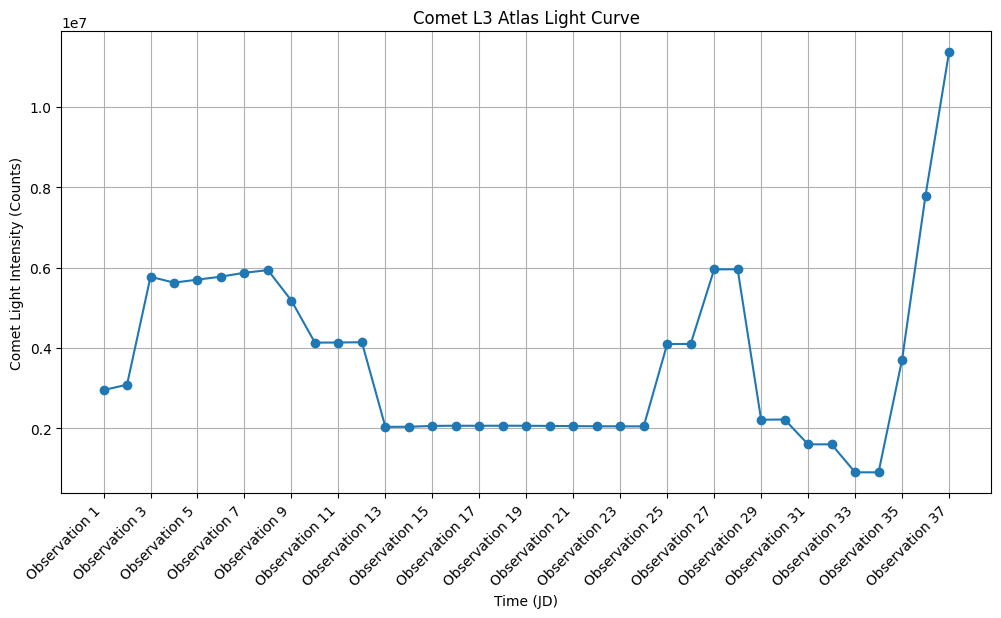

In [ ]:
times = []  # To store the time of each observation
light_intensities = []  # To store the comet's light intensity

for image_path in fm.all_images:
    image = FITSImage(image_path)
    times.append(image.header['J_DATE'])

    # Use the same aperture definition for all images
    aperture = ref.sources[18].circular_aperture(30, scale=False)

    # Calculate the total counts within the aperture using do_photometry
    light_intensity = aperture.do_photometry(image.data)
    light_intensities.append(light_intensity)

# Reshape to consistent shape (if needed) and extract data for plotting
plot_intensities = [intensity[0] for intensity in light_intensities]  # Extracting the first element for plotting

new_labels = [f'Observation {i+1}' for i in range(37)]

plt.figure(figsize=(12, 6))
plt.plot(times, plot_intensities, marker='o', linestyle='-')
plt.xlabel('Time (JD)')
plt.ylabel('Comet Light Intensity (Counts)')
plt.title('Comet L3 Atlas Light Curve')
plt.grid(True)

plt.xticks(times[::2], labels=new_labels[::2], rotation=45, ha="right" )  # Update the tick labels and rotate

plt.show()